In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [ ]:
# Load the provided JSON file
file_path = 'DE_L_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2 1.json'
with open(file_path, 'r') as file:
    data = json.load(file)
    
# Create the combined data dictionary according to the provided mapping
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

unique_producers = set(combined_data['Y_manufacturers_producing_period'].keys())
unique_vaccines = set(combined_data['Q_commitment_amounts'].keys())

In [ ]:
# Load the capacity data
file_path = 'adjusted_capacity.xlsx'
capacity_df = pd.read_excel(file_path, sheet_name='Sheet1')
capacity_df

In [ ]:
# aggregated_data = []
vaccines = []
producers = []
years = []
scenarios = []

for vaccine, producer_data in combined_data['X_production_amounts'].items():
    # print(f"Vaccine: {vaccine}")
    vaccines.append(vaccine)
    # print(producer_data)
    for producer, year_data in producer_data.items():
        # print(f"Producer: {producer}")
        producers.append(producer)
        # print(year_data)
        for year, scenario_data in year_data.items():
            # print(f"Year: {year}")
            years.append(year)
            # print(scenario_data)
            for scenario, amount in scenario_data.items():
                # print(f"scenario number: {scenario}")
                scenarios.append(scenario)
                # print(f"amount: {amount}")

vaccines = list(set(vaccines))
scenarios = list(set(scenarios))
producers = list(set(producers))
years = list(set(years))



In [ ]:
scenarios

In [ ]:
#blank nested dict - re-ordered data

aggregated_data = {}
for scenario in scenarios:
    aggregated_data[scenario] = {}
    for producer in producers:
        aggregated_data[scenario][producer] = {}
        for vaccine in vaccines:
            aggregated_data[scenario][producer][vaccine] = {}
            for year in years:
                aggregated_data[scenario][producer][vaccine][year] = {}

In [ ]:
for vaccine, producer_data in combined_data['X_production_amounts'].items():
    for producer, year_data in producer_data.items():
        for year, scenario_data in year_data.items():
            for scenario, amount in scenario_data.items():
                aggregated_data[scenario][producer][vaccine][year] = amount

In [ ]:
# # Save the unique producers to a JSON file using an alternative method
# output_file_path = 'flipped_data.json'

# with open(output_file_path, 'w') as json_file:
#     json.dump((aggregated_data), json_file)

# Plot: Scenario, Producer, aggregated X per year

In [ ]:
# Function to plot adjusted stacked bar chart for each company, ordered by years (1 to 10)
def plot_adjusted_stacked_bar(data, title, capacity_data, scenario):
    ordered_years = [str(year) for year in range(1, 11)]
    aggregated_data = {}

    # Aggregate data for each vaccine
    for vaccine, values in data.items():
        aggregated_data[vaccine] = {year: values.get(year, 0) for year in ordered_years}

    df = pd.DataFrame(aggregated_data, index=ordered_years).fillna(0)
    ax = df.plot(kind='bar', stacked=True, figsize=(10, 6))

    # Plot line chart on the same axis
    # Convert capacity_data_dict to a DataFrame
    capacity_df = capacity_data.set_index('Manufacturer').T[title]
    capacity_df.index = ordered_years
    capacity_df.plot(ax=ax, color='black', marker='o', linewidth=2, legend=False)

    # plt.title(title)
    plt.title(f"{title} - Scenario: {scenario}")

    plt.xlabel('Years')
    plt.ylabel('Values')
    plt.legend(title='Vaccines')

    # Ensure the 'graphs' folder exists
    if not os.path.exists('scenario_graphs'):
        os.makedirs('scenario_graphs')

    # Construct dynamic filename with folder path
    filename = os.path.join('scenario_graphs', f"scenario_{scenario}_{company}.jpg")

    # Save the figure
    plt.savefig(filename, format='jpg')
        
    plt.show()




In [ ]:
# # Write data to JSON file
# with open('aggregated_data.json', 'w') as file:
#     json.dump(aggregated_data, file)

In [ ]:
for scenario, data in aggregated_data.items():
    for company, vaccine_data in data.items():
        plot_adjusted_stacked_bar(vaccine_data, company, capacity_df, scenario)

# Plot: Scenario, Specified vaccine, aggregated by producer

#### i.e. Penta, all producers

In [ ]:
def plot_vaccine_production(scenario, vaccine):
    # Create a DataFrame for the specified scenario and vaccine
    data = aggregated_data[scenario]
    df = pd.DataFrame({producer: data[producer][vaccine] for producer in data})
    
    # Sort the DataFrame by the year column, ensuring the x-axis is from 1 to 10
    df = df.sort_index(axis=0, key=lambda x: x.astype(int))
    
    # Plotting the data
    df.plot(kind='bar', stacked=True, figsize=(12, 8))
    plt.title(f"Vaccine Production for {vaccine} in Scenario {scenario}")
    plt.xlabel("Year")
    plt.ylabel("Amount Produced")
    plt.legend(title="Producer")
    plt.show()


# Example usage for scenario '65' and vaccine 'PCV'
plot_vaccine_production('1', 'Penta')


In [ ]:
def plot_vaccine_production(scenario, vaccines):
    # Create a combined DataFrame for the specified scenario and list of vaccines
    combined_df = pd.DataFrame()

    for vaccine in vaccines:
        data = aggregated_data[scenario]
        df = pd.DataFrame({producer: data[producer][vaccine] for producer in data})
        df = df.sort_index(axis=0, key=lambda x: x.astype(int))
        df['Year'] = df.index
        df['Vaccine'] = vaccine
        combined_df = pd.concat([combined_df, df])

    # Reset index for melting
    combined_df.reset_index(drop=True, inplace=True)

    # Melt the DataFrame for stacked bar plotting
    melted_df = combined_df.melt(id_vars=['Year', 'Vaccine'], var_name='Producer', value_name='Amount')

    # Plotting the data
    fig, axes = plt.subplots(len(vaccines), 1, figsize=(12, 8 * len(vaccines)), sharex=True)

    if len(vaccines) == 1:
        axes = [axes]

    for i, vaccine in enumerate(vaccines):
        df = melted_df[melted_df['Vaccine'] == vaccine]
        df_pivot = df.pivot(index='Year', columns='Producer', values='Amount')
        df_pivot.plot(kind='bar', stacked=True, ax=axes[i])
        axes[i].set_title(f"Vaccine Production for {vaccine} in Scenario {scenario}")
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("Amount Produced")

    plt.tight_layout()

        # Ensure the 'graphs' folder exists
    if not os.path.exists('vaccine_graphs'):
        os.makedirs('vaccine_graphs')

    # Construct dynamic filename with folder path
    filename = os.path.join('vaccine_graphs', f"scenario_{scenario}_{vaccine}.jpg")

    # Save the figure
    plt.savefig(filename, format='jpg')

    plt.show()



In [ ]:
for scenario, data in aggregated_data.items():
    plot_vaccine_production(scenario, unique_vaccines)

In [ ]:
def plot_vaccine_production(scenario, vaccines):
    for vaccine in vaccines:
        # Create a DataFrame for the specified scenario and vaccine
        data = aggregated_data[scenario]
        df = pd.DataFrame({producer: data[producer][vaccine] for producer in data})
        df = df.sort_index(axis=0, key=lambda x: x.astype(int))
        df['Year'] = df.index

        # Plotting the data
        df.plot(kind='bar', stacked=True, figsize=(12, 8))
        plt.title(f"Vaccine Production for {vaccine} in Scenario {scenario}")
        plt.xlabel("Year")
        plt.ylabel("Amount Produced")
        plt.legend(title="Producer")

        # Ensure the 'graphs' folder exists
        if not os.path.exists('vaccine_graphs'):
            os.makedirs('vaccine_graphs')

     # Construct dynamic filename with folder path
        filename = os.path.join('vaccine_graphs', f"scenario_{scenario}_{vaccine}.jpg")

        # Save the figure
        plt.savefig(filename, format='jpg')        
        
        plt.show()

for scenario, data in aggregated_data.items():
    plot_vaccine_production(scenario, unique_vaccines)


# Plot per producer, with stacked bars, and bars for each scenario

In [ ]:

# Transform data into a DataFrame
def transform_data(data):
    records = []
    for scenario, producers in data.items():
        for producer, vaccines in producers.items():
            for vaccine, years in vaccines.items():
                for year, value in years.items():
                    if isinstance(value, (int, float)):
                        records.append({
                            'Scenario': int(scenario),
                            'Producer': producer,
                            'Vaccine': vaccine,
                            'Year': int(year),
                            'Value': value
                        })
    return pd.DataFrame(records)

df = transform_data(aggregated_data)

# Define a color scheme for vaccines
vaccine_colors = {
    'TT': '#1f77b4',
    'Hib': '#ff7f0e',
    'MR': '#2ca02c',
    'M': '#d62728',
    'Hexa': '#9467bd',
    'HPV': '#8c564b',
    'OPV': '#e377c2',
    'Penta': '#7f7f7f',
    'Td': '#bcbd22',
    'DTwP': '#17becf',
    'PCV': '#1f77b4',
    'Rotavirus': '#ff7f0e',
    'DTwP-Hib': '#2ca02c',
    'MMR': '#d62728',
    'IPV': '#9467bd',
    'HepB': '#8c564b',
    'DT': '#e377c2'
}

producers = df['Producer'].unique()
# scenarios = sorted(df['Scenario'].unique())  # Ensure scenarios are sorted
scenarios = [2,1,3,4]
years = sorted(df['Year'].unique())

for producer in producers:
    fig, ax = plt.subplots(figsize=(10, 6))
    plotted_vaccines = set()  # Track which vaccines have been plotted for the legend
    for scenario in scenarios:
        sub_df = df[(df['Producer'] == producer) & (df['Scenario'] == scenario)]
        pivot_df = sub_df.pivot(index='Year', columns='Vaccine', values='Value').fillna(0)
        bottom = None
        for vaccine in pivot_df.columns:
            color = vaccine_colors.get(vaccine, '#333333')  # Default color if not in the scheme
            label = vaccine if vaccine not in plotted_vaccines else None  # Only label first occurrence
            ax.bar(pivot_df.index + (scenario - 1) * 0.2, pivot_df[vaccine], width=0.2, label=label, color=color, edgecolor='black', bottom=bottom)
            if label:
                plotted_vaccines.add(vaccine)
            if bottom is None:
                bottom = pivot_df[vaccine]
            else:
                bottom += pivot_df[vaccine]
    
    ax.set_title(f'Producer: {producer}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Value')
    ax.legend(title='Vaccines')
    plt.xticks(ticks=years, labels=years)
    plt.show()


   Scenario Producer Vaccine  Year         Value
0         3   Pfizer     PCV     3  46663.037212
1         3   Pfizer     PCV     2  45534.092764
2         3   Pfizer     PCV     7  46304.274753
3         3   Pfizer     PCV     5  46375.585238
4         3   Pfizer     PCV     6  46233.183236


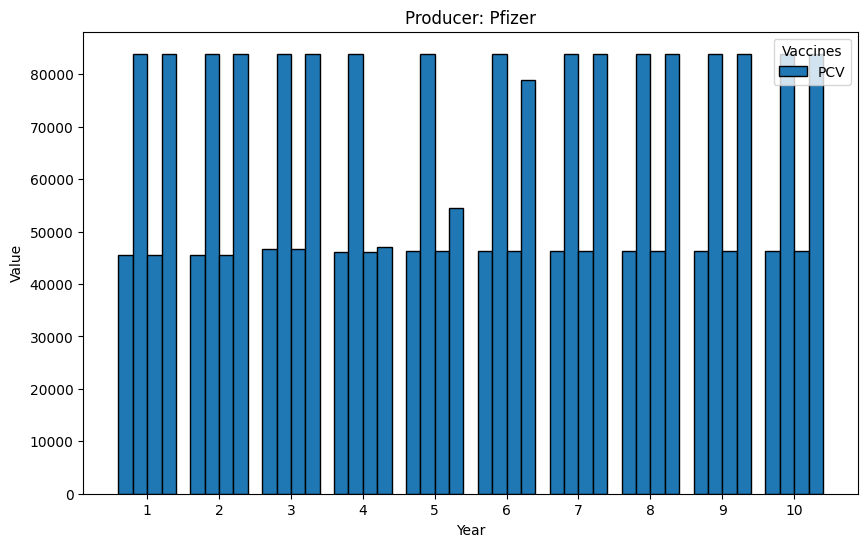

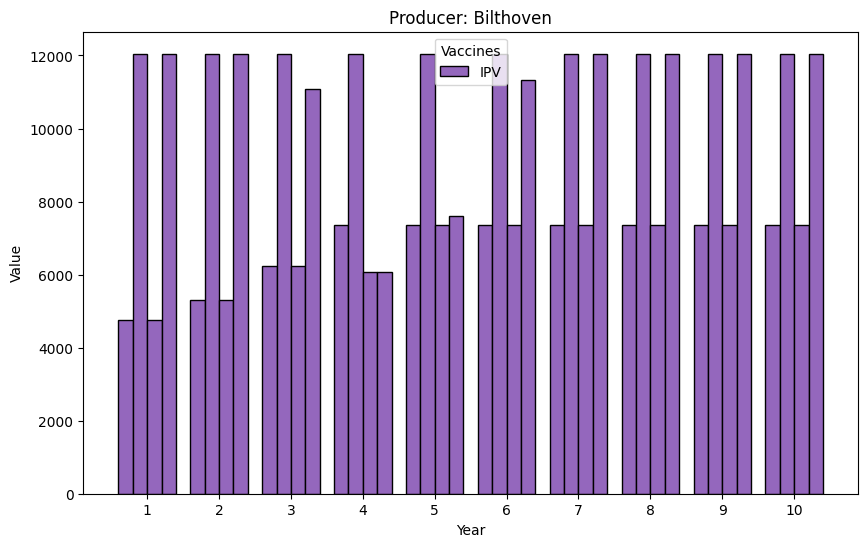

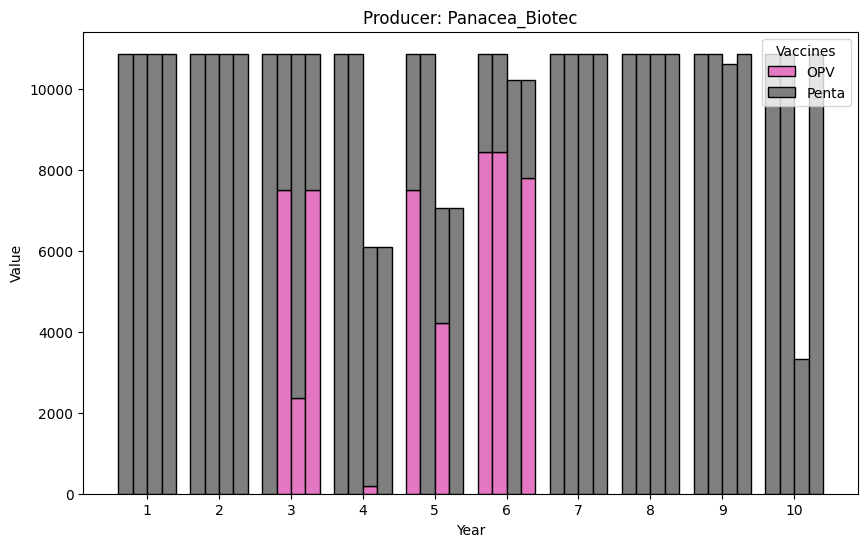

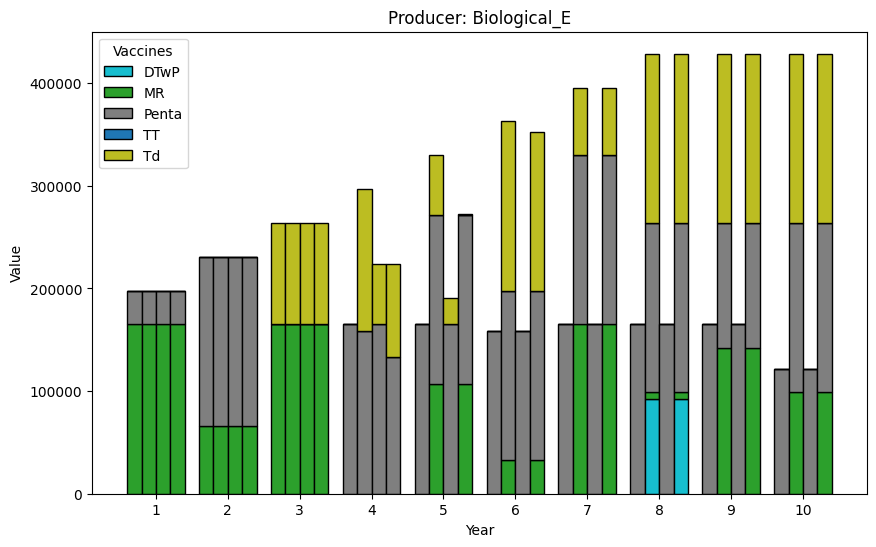

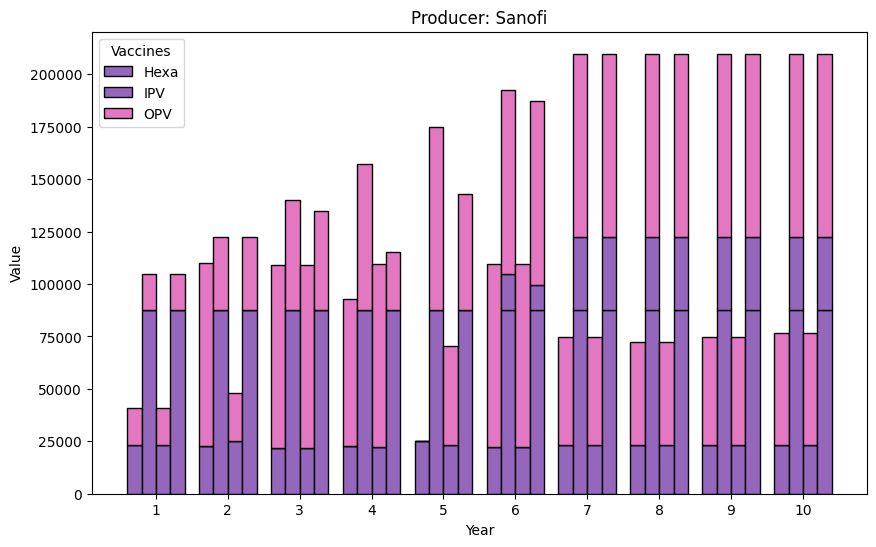

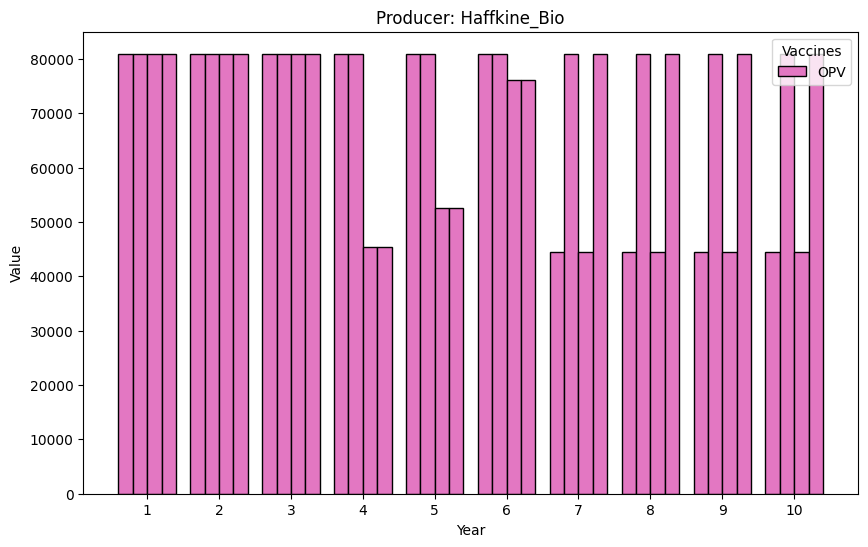

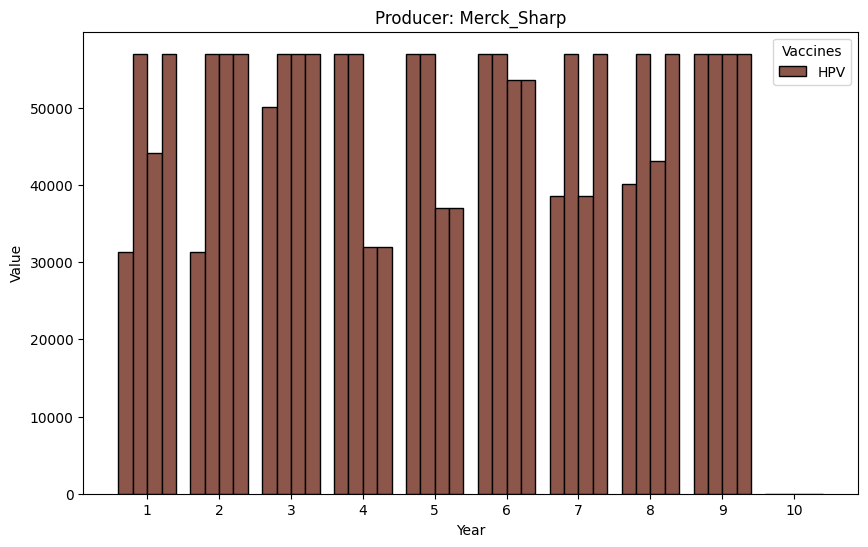

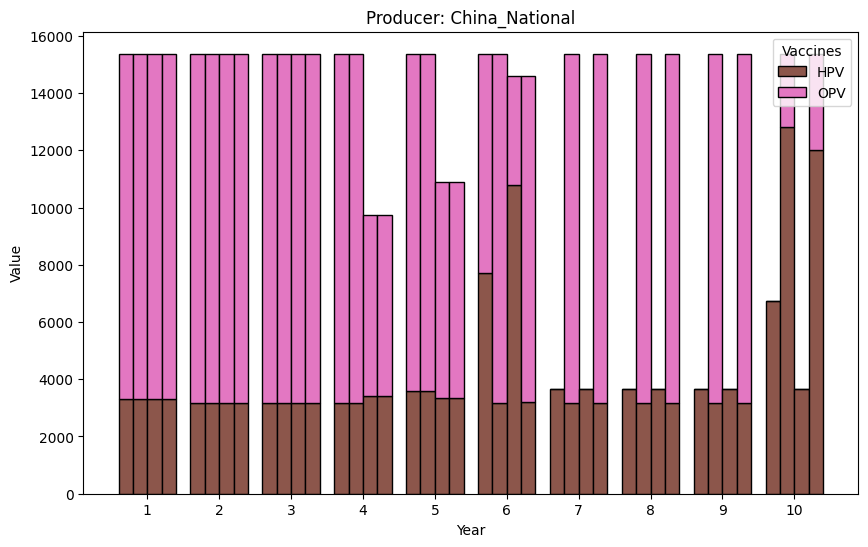

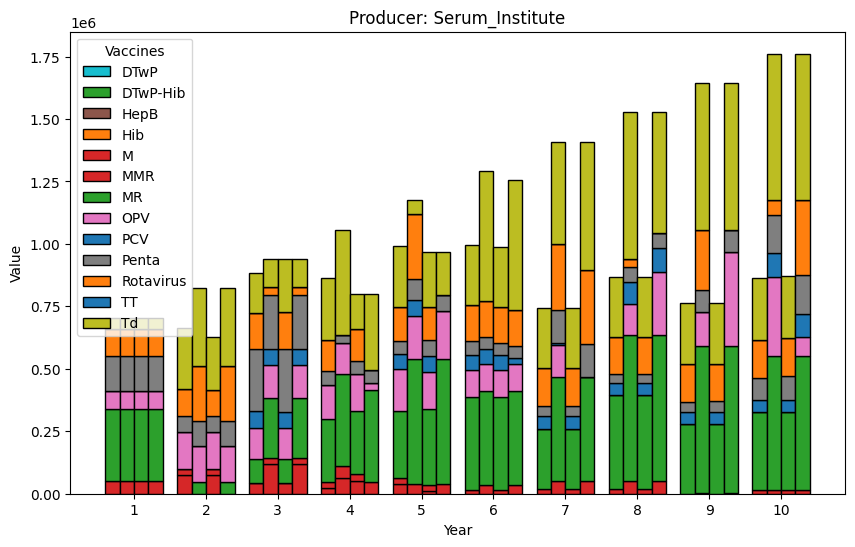

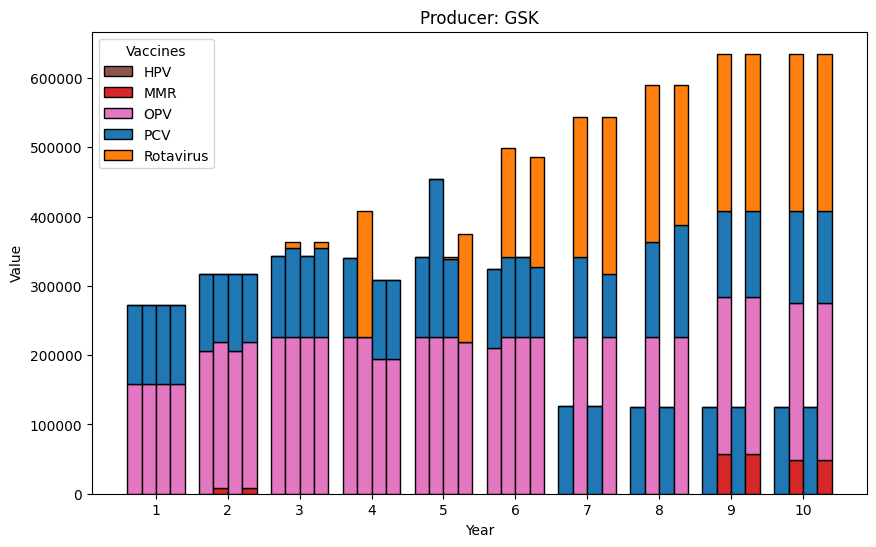

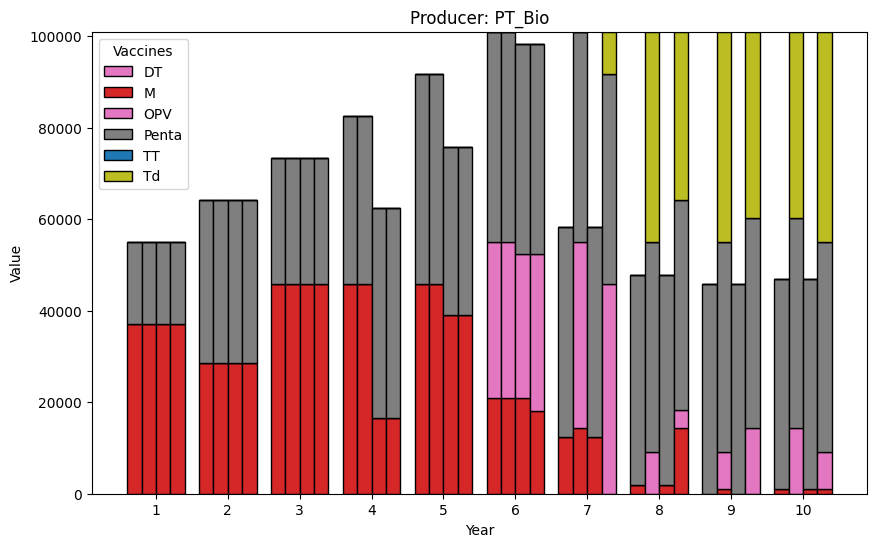

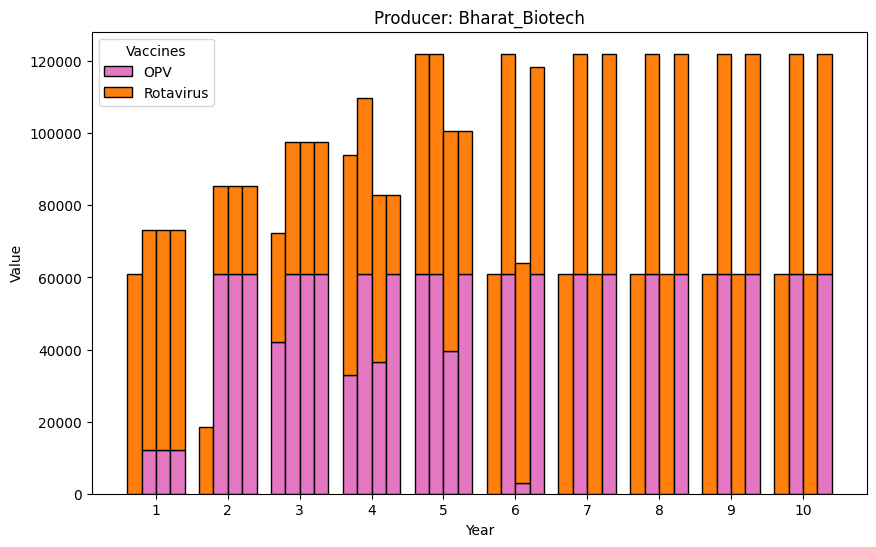

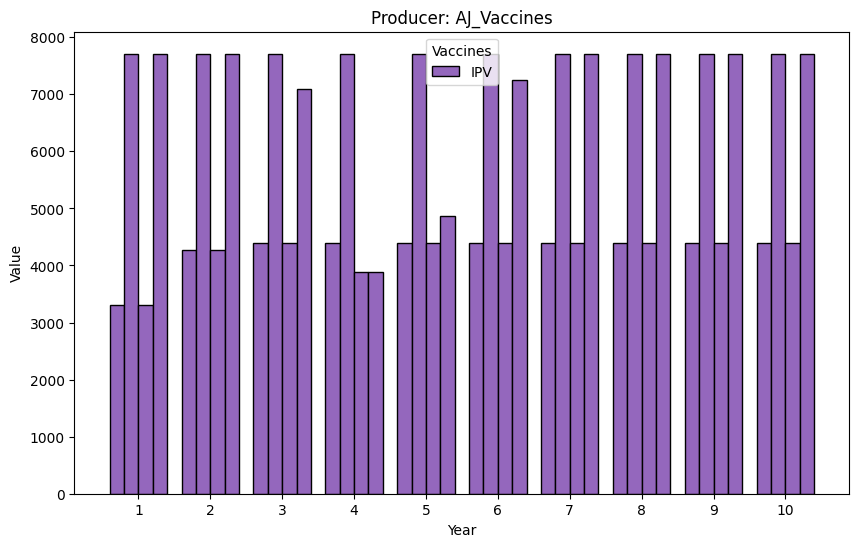

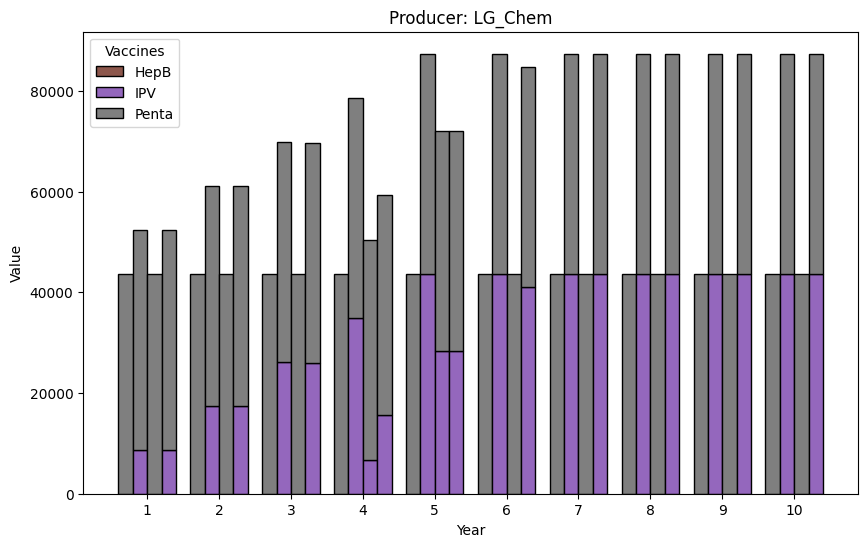

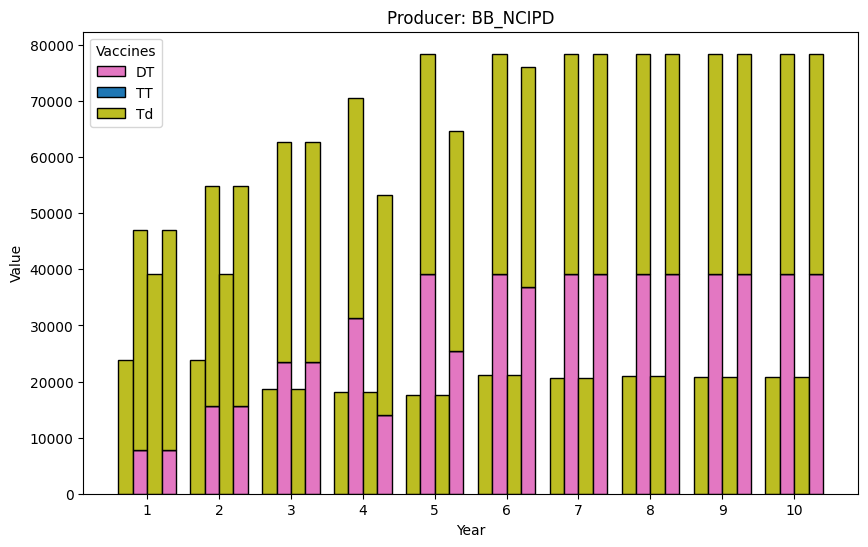

In [82]:
# Transform data into a DataFrame
def transform_data(data):
    records = []
    for scenario, producers in data.items():
        for producer, vaccines in producers.items():
            for vaccine, years in vaccines.items():
                for year, value in years.items():
                    if isinstance(value, (int, float)):
                        records.append({
                            'Scenario': int(scenario),
                            'Producer': producer,
                            'Vaccine': vaccine,
                            'Year': int(year),
                            'Value': value
                        })
    return pd.DataFrame(records)

df = transform_data(aggregated_data)

# Check the DataFrame
print(df.head())

# Define a color scheme for vaccines
vaccine_colors = {
    'TT': '#1f77b4',
    'Hib': '#ff7f0e',
    'MR': '#2ca02c',
    'M': '#d62728',
    'Hexa': '#9467bd',
    'HPV': '#8c564b',
    'OPV': '#e377c2',
    'Penta': '#7f7f7f',
    'Td': '#bcbd22',
    'DTwP': '#17becf',
    'PCV': '#1f77b4',
    'Rotavirus': '#ff7f0e',
    'DTwP-Hib': '#2ca02c',
    'MMR': '#d62728',
    'IPV': '#9467bd',
    'HepB': '#8c564b',
    'DT': '#e377c2'
}

producers = df['Producer'].unique()
scenarios = [2, 1, 3, 4]  # Ensure scenarios are in the desired order
years = sorted(df['Year'].unique())

for producer in producers:
    fig, ax = plt.subplots(figsize=(10, 6))
    plotted_vaccines = set()  # Track which vaccines have been plotted for the legend
    for i, scenario in enumerate(scenarios):
        sub_df = df[(df['Producer'] == producer) & (df['Scenario'] == scenario)]
        pivot_df = sub_df.pivot(index='Year', columns='Vaccine', values='Value').fillna(0)
        bottom = None
        for vaccine in pivot_df.columns:
            color = vaccine_colors.get(vaccine, '#333333')  # Default color if not in the scheme
            label = vaccine if vaccine not in plotted_vaccines else None  # Only label first occurrence
            ax.bar(pivot_df.index + (i - 1.5) * 0.2, pivot_df[vaccine], width=0.2, label=label, color=color, edgecolor='black', bottom=bottom)
            if label:
                plotted_vaccines.add(vaccine)
            if bottom is None:
                bottom = pivot_df[vaccine]
            else:
                bottom += pivot_df[vaccine]
    
    ax.set_title(f'Producer: {producer}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Value')
    ax.legend(title='Vaccines')
    plt.xticks(ticks=years, labels=years)
    plt.show()
